In [4]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [5]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

In [6]:
# Local project root
PROJECT_ROOT = Path("/Users/zhengzikun/Desktop/MLDS414/final_project")

# Add repo root to Python path so src imports work
sys.path.append(str(PROJECT_ROOT))

# Output folders
for subdir in [
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/samples",
    "outputs/models",
]:
    (PROJECT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Setup complete.")


PROJECT_ROOT: /Users/zhengzikun/Desktop/MLDS414/final_project
Setup complete.


In [7]:
!pip -q uninstall -y datasets
!pip -q install datasets==2.20.0 huggingface_hub==0.23.5 pyarrow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.55.4 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 0.23.5 which is incompatible.


In [8]:
import datasets
from datasets import load_dataset

print("datasets version:", datasets.__version__)

DATASET_NAME = "allenai/multi_lexsum"
DATASET_VERSION = "v20230518"

multi_lexsum = load_dataset(
    DATASET_NAME,
    name=DATASET_VERSION,
    trust_remote_code=True
)

print("Dataset loaded successfully.")
print("Splits:", list(multi_lexsum.keys()))

for split_name, split_data in multi_lexsum.items():
    print("\n" + "=" * 80)
    print(f"Split: {split_name}")
    print("Number of rows:", len(split_data))
    print("Feature names:")
    print(list(split_data.features.keys()))
    print("\nFeature details:")
    print(split_data.features)

datasets version: 2.20.0
Dataset loaded successfully.
Splits: ['train', 'validation', 'test']

Split: train
Number of rows: 3177
Feature names:
['id', 'sources', 'sources_metadata', 'summary/long', 'summary/short', 'summary/tiny', 'case_metadata']

Feature details:
{'id': Value(dtype='string', id=None), 'sources': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'sources_metadata': Sequence(feature={'doc_id': Value(dtype='string', id=None), 'doc_type': Value(dtype='string', id=None), 'doc_title': Value(dtype='string', id=None), 'parser': Value(dtype='string', id=None), 'is_ocr': Value(dtype='bool', id=None), 'url': Value(dtype='string', id=None)}, length=-1, id=None), 'summary/long': Value(dtype='string', id=None), 'summary/short': Value(dtype='string', id=None), 'summary/tiny': Value(dtype='string', id=None), 'case_metadata': {'case_name': Value(dtype='string', id=None), 'case_type': Value(dtype='string', id=None), 'filing_date': Value(dtype='string', id=None), 'f

In [9]:
def build_multilexsum_dataframe(dataset_dict):
    """
    Convert the HuggingFace DatasetDict into one pandas DataFrame.

    Important:
    - source_text is built by joining all source documents for each case.
    - class_action_sought and case_type are nested inside case_metadata.
    - reference summaries are stored as summary/long, summary/short, summary/tiny.
    """
    rows = []

    for split_name, split_data in dataset_dict.items():
        for item in split_data:
            metadata = item.get("case_metadata", {}) or {}
            sources = item.get("sources", []) or []

            rows.append({
                "split": split_name,
                "case_id": item.get("id"),
                "source_text": "\n\n".join(sources),
                "num_source_docs": len(sources),
                "ref_long": item.get("summary/long"),
                "ref_short": item.get("summary/short"),
                "ref_tiny": item.get("summary/tiny"),
                "case_metadata": metadata,
                "case_name": metadata.get("case_name"),
                "case_type": metadata.get("case_type"),
                "class_action_sought": metadata.get("class_action_sought"),
                "filing_year": metadata.get("filing_year"),
                "case_ongoing": metadata.get("case_ongoing"),
                "prevailing_party": metadata.get("prevailing_party"),
            })

    return pd.DataFrame(rows)


df = build_multilexsum_dataframe(multi_lexsum)

print("DataFrame shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

print("\nSplit counts:")
display(df["split"].value_counts())

print("\nRequired column missing values:")
required_cols = [
    "split",
    "case_id",
    "source_text",
    "ref_long",
    "ref_short",
    "ref_tiny",
    "case_metadata",
    "class_action_sought",
    "case_type",
]
display(df[required_cols].isna().sum())


DataFrame shape: (4539, 14)

Columns:
['split', 'case_id', 'source_text', 'num_source_docs', 'ref_long', 'ref_short', 'ref_tiny', 'case_metadata', 'case_name', 'case_type', 'class_action_sought', 'filing_year', 'case_ongoing', 'prevailing_party']


,split,case_id,source_text,num_source_docs,ref_long,ref_short,ref_tiny,case_metadata,case_name,case_type,class_action_sought,filing_year,case_ongoing,prevailing_party
0,train,EE-AL-0045,Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6\n\nIN\n\nTHE\n\nUNITED\n\nSTATES\n\nDISTRICT\n\nFILD COUR T\n\nP19\n\n.05\n\nNl\n\nel\n\n.s\n\nFOR THE SOUTHERN DISTRICT OF ALABAMA\n...,4,"On September 15, 2005, the Equal Employment Opportunity Commission (EEOC) filed suit against House of Philadelphia, Inc., on behalf of an employee who was allegedly fired because she was pregnant....","Equal Employment Opportunity Commission brought a Title VII sex discrimination case against House of Philadelphia, Inc., on behalf of an employee who was allegedly fired because she was pregnant. ...",None,"{'case_name': 'EEOC v. House of Philadelphia Center, Inc.', 'case_type': 'Equal Employment', 'filing_date': '2005-09-15', 'filing_year': '2005', 'case_ongoing': 'No', 'case_ongoing_record_time': '...","EEOC v. House of Philadelphia Center, Inc.",Equal Employment,No,2005,No,Plaintiff
1,train,PB-NJ-0003,"Case 3:05-cv-01784-SRC-JJH Document 2 Filed 05/19/2005 Page 1 of 22\n\nNEW JERSEY PROTECTION AND ADVOCACY, INC. BY: WILLIAM EMMETT DWYER, ESQ. (WD 6894)\nHELEN C. DODICK, ESQ. (HD 4960) 210 SOUTH ...",4,NOTE: This is one of three identically named cases in the Clearinghouse. For the 2005 case generally challenging the unnecessary institutionalization of individuals with disabilities in New Jerse...,"The case was brought by a non-profit organization against the state of New Jersey seeking declaratory and injunctive relief. On July 29, 2009, the parties reached a settlement in favor of the pla...",None,"{'case_name': 'Disability Rights New Jersey v. Velez', 'case_type': 'Public Benefits / Government Services', 'filing_date': '2005-04-05', 'filing_year': '2005', 'case_ongoing': 'No', 'case_ongoing...",Disability Rights New Jersey v. Velez,Public Benefits / Government Services,No,2005,No,Plaintiff
2,train,EE-FL-0136,"Case 9:07-cv-80713-KAM Document 1 Entered on FLSD Docket 08/09/2007 Page 1 of 5\n\nIN THE UNITED STATES DISTRICT COURT FOR THE SOUTHERN DISTRICT OF FLORIDA\n\n-W\n\nZD:71iUG -9\n\nFt1\n\nI\n\n. ,....",3,"On August 9, 2007, the United States Department of Justice (""DOJ"") filed a lawsuit in the U.S. District Court for the Southern District of Florida under Title VII of the Civil Rights Act of 1964 a...",None,None,"{'case_name': 'United States v. Palm Beach County', 'case_type': 'Equal Employment', 'filing_date': '2007-08-09', 'filing_year': '2007', 'case_ongoing': 'No', 'case_ongoing_record_time': '2022-05-...",United States v. Palm Beach County,Equal Employment,No,2007,No,Mixed



Split counts:


split
train         3177
test           908
validation     454
Name: count, dtype: int64


Required column missing values:


split                     0
case_id                   0
source_text               0
ref_long                  0
ref_short              1401
ref_tiny               2936
case_metadata             0
class_action_sought       0
case_type                 0
dtype: int64

In [10]:
def word_count(text):
    if pd.isna(text) or text is None:
        return 0
    return len(str(text).split())

df["source_word_count"] = df["source_text"].apply(word_count)
df["ref_long_word_count"] = df["ref_long"].apply(word_count)
df["ref_short_word_count"] = df["ref_short"].apply(word_count)
df["ref_tiny_word_count"] = df["ref_tiny"].apply(word_count)

length_cols = [
    "source_word_count",
    "ref_long_word_count",
    "ref_short_word_count",
    "ref_tiny_word_count",
    "num_source_docs",
]

print("Length summary statistics:")
display(df[length_cols].describe().T)

print("\nLargest source documents:")
display(
    df[["split", "case_id", "case_name", "case_type", "source_word_count", "num_source_docs"]]
    .sort_values("source_word_count", ascending=False)
    .head(10)
)

print("\nSmallest non-empty source documents:")
display(
    df[df["source_word_count"] > 0][["split", "case_id", "case_name", "case_type", "source_word_count", "num_source_docs"]]
    .sort_values("source_word_count", ascending=True)
    .head(10)
)


Length summary statistics:


,count,mean,std,min,25%,50%,75%,max
source_word_count,4539.0,61538.587574,145513.077494,961.0,8964.5,24546.0,61792.0,3565130.0
ref_long_word_count,4539.0,545.719982,477.217516,65.0,222.0,419.0,705.0,8481.0
ref_short_word_count,4539.0,78.100022,72.319925,0.0,0.0,78.0,117.0,671.0
ref_tiny_word_count,4539.0,7.480502,11.228162,0.0,0.0,0.0,16.0,43.0
num_source_docs,4539.0,8.838731,11.041669,1.0,4.0,6.0,10.0,336.0



Largest source documents:


,split,case_id,case_name,case_type,source_word_count,num_source_docs
805,train,IM-HI-0004,Hawaii v. Trump,Immigration and/or the Border,3565130,336
3465,validation,PN-AZ-0003,Melendres v. Arpaio,Policing,3068996,92
4241,test,PN-MI-0001,"U.S. v. City of Detroit, Michigan",Policing,3022488,97
575,train,IM-MD-0004,International Refugee Assistance Project (“IRAP”) v. Trump,Immigration and/or the Border,2906310,265
1993,train,PC-CA-0002,Coleman v. Brown,Prison Conditions,2332663,113
543,train,IM-CA-0002,Flores v. Reno,Immigration and/or the Border,1484162,98
3319,validation,JC-OR-0010,Prison Legal News v. Columbia County,Jail Conditions,1376685,78
968,train,EE-NY-0260,Gulino v. New York City Board of Education,Equal Employment,1341831,30
47,train,IM-MI-0005,Hamama v. Adducci,Immigration and/or the Border,1314160,122
1407,train,PN-NM-0002,U.S. v. City of Albuquerque,Policing,1272670,37



Smallest non-empty source documents:


,split,case_id,case_name,case_type,source_word_count,num_source_docs
1033,train,PB-TX-0005,Nuckols v. Perry,Public Benefits / Government Services,961,3
2512,train,EE-VA-0127,"Woodruff v. DTI Associates, Inc.",Equal Employment,1103,2
2959,train,EE-MD-0135,"United States of America v. The New Baltimore City Board of School Commissioners, Its Chief Executive Officer, and the Baltimore City Public School System",Equal Employment,1123,2
3250,validation,EE-TX-0425,"United States v. City of Dallas, Texas",Equal Employment,1203,3
936,train,EE-TX-0229,"EEOC v. MINORITY OPPORTUNITY NEWS, INC.",Equal Employment,1344,3
2091,train,EE-NC-0058,"EEOC v. KNIFE & FORK ON SHARON AMITY, INC.",Equal Employment,1491,4
304,train,EE-IN-0122,"United States of America v. School City of East Chicago, Indiana",Equal Employment,1619,3
40,train,EE-MI-0152,EEOC v. Servicing Solutions,Equal Employment,1627,3
2716,train,EE-NC-0109,EEOC v. T & D ELECTRIC COMPANY OF BURLINGTON INC,Equal Employment,1665,2
3372,validation,EE-LA-0004,EEOC v. AMPACE FREIGHTLINES INC (D/B/A MERCHANTS DUTCH),Equal Employment,1704,3


### Key finding: long-document challenge

The source documents are much longer than typical NLP classification inputs. The median case has about 24.5K words, while the largest case exceeds 3.5M words. This confirms that direct transformer summarization is not practical without chunking or truncation. For this project, summarization will use a small sample and a hierarchical chunking strategy, while classification will use TF-IDF features over cleaned text.

class_action_sought distribution:


,count,percentage
class_action_sought,,
No,3026,66.67
Yes,1510,33.27
Unknown,3,0.07


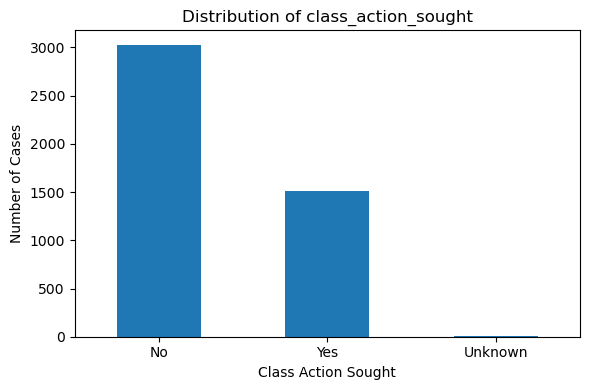

In [11]:
class_counts = df["class_action_sought"].value_counts(dropna=False)
class_pct = df["class_action_sought"].value_counts(normalize=True, dropna=False).mul(100).round(2)

class_action_table = pd.DataFrame({
    "count": class_counts,
    "percentage": class_pct
})

print("class_action_sought distribution:")
display(class_action_table)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Distribution of class_action_sought")
plt.xlabel("Class Action Sought")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "class_action_sought_distribution.png"
plt.savefig(fig_path, dpi=150)
plt.show()


### Key finding: class-action target imbalance

The `class_action_sought` target is moderately imbalanced. About two-thirds of cases did not seek class action, while about one-third did. The `Unknown` category is extremely rare, with only 3 cases, so it should be removed or handled separately before binary classification.

Number of unique case types: 24

Top 15 case types:


,count,percentage
case_type,,
Equal Employment,1579,34.79
Immigration and/or the Border,523,11.52
Prison Conditions,424,9.34
Jail Conditions,303,6.68
Public Benefits / Government Services,288,6.35
Policing,201,4.43
Criminal Justice (Other),184,4.05
Speech and Religious Freedom,173,3.81
National Security,137,3.02


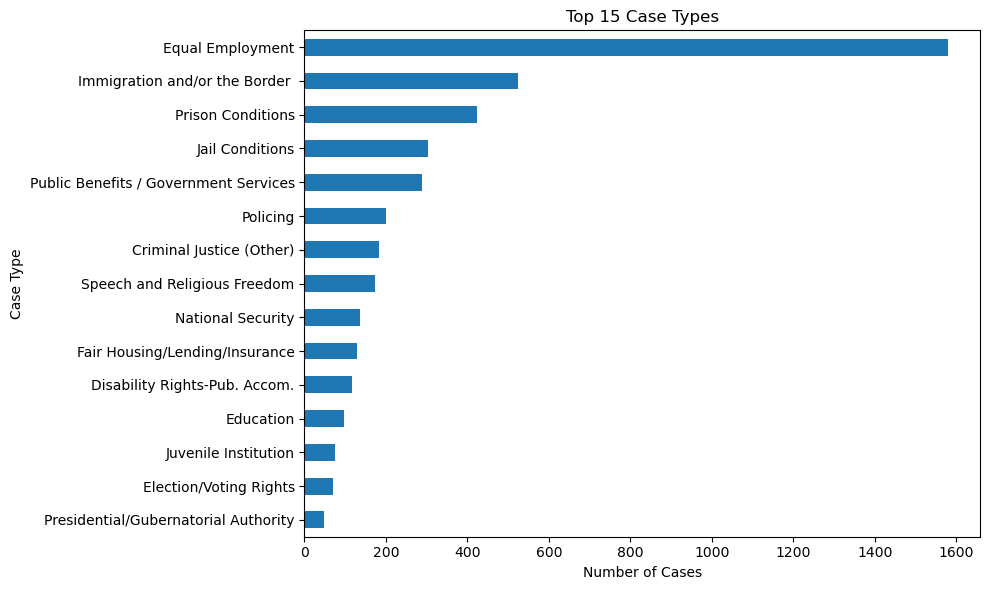

In [12]:
case_type_counts = df["case_type"].value_counts(dropna=False)
case_type_pct = df["case_type"].value_counts(normalize=True, dropna=False).mul(100).round(2)

case_type_table = pd.DataFrame({
    "count": case_type_counts,
    "percentage": case_type_pct
})

print("Number of unique case types:", df["case_type"].nunique(dropna=True))
print("\nTop 15 case types:")
display(case_type_table.head(15))

plt.figure(figsize=(10, 6))
case_type_counts.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Case Types")
plt.xlabel("Number of Cases")
plt.ylabel("Case Type")
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "top_15_case_types.png"
plt.savefig(fig_path, dpi=150)
plt.show()


### Key finding: imbalanced multiclass target

The `case_type` target has 24 categories, but the distribution is highly skewed. `Equal Employment` is the largest group, representing about 34.8% of all cases. For the classification model, I will focus on the most frequent case types, such as the top 6 categories, to keep the multiclass task meaningful while avoiding extremely sparse classes.

Summary availability:


,summary_level,total_cases,non_missing,missing,non_empty,available_percentage
0,ref_long,4539,4539,0,4539,100.00
1,ref_short,4539,3138,1401,3138,69.13
2,ref_tiny,4539,1603,2936,1603,35.32


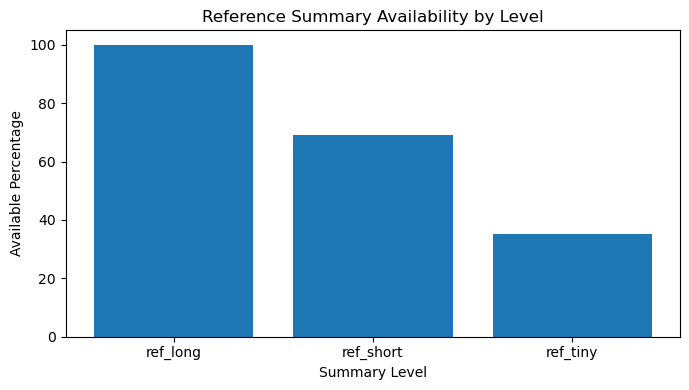

In [13]:
summary_cols = ["ref_long", "ref_short", "ref_tiny"]

summary_availability = []

for col in summary_cols:
    total = len(df)
    non_missing = df[col].notna().sum()
    missing = df[col].isna().sum()
    non_empty = df[col].fillna("").astype(str).str.strip().ne("").sum()

    summary_availability.append({
        "summary_level": col,
        "total_cases": total,
        "non_missing": non_missing,
        "missing": missing,
        "non_empty": non_empty,
        "available_percentage": round(non_empty / total * 100, 2)
    })

summary_availability_df = pd.DataFrame(summary_availability)

print("Summary availability:")
display(summary_availability_df)

plt.figure(figsize=(7, 4))
plt.bar(
    summary_availability_df["summary_level"],
    summary_availability_df["available_percentage"]
)
plt.title("Reference Summary Availability by Level")
plt.xlabel("Summary Level")
plt.ylabel("Available Percentage")
plt.ylim(0, 105)
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "summary_availability.png"
plt.savefig(fig_path, dpi=150)
plt.show()


### Key finding: reference summary coverage differs by granularity

Every case has a long reference summary, but only about 69.1% have a short summary and about 35.3% have a tiny summary. This means summary evaluation should be filtered by summary level: long-summary ROUGE can use all cases, while short and tiny ROUGE should only use cases with non-empty reference summaries.

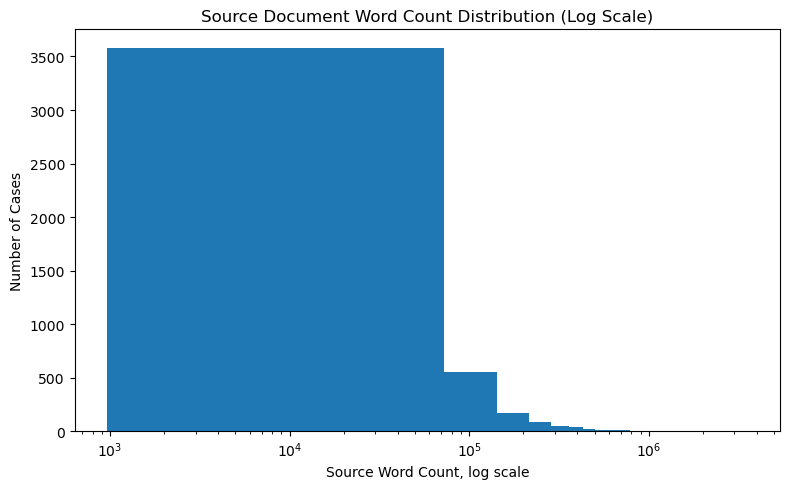

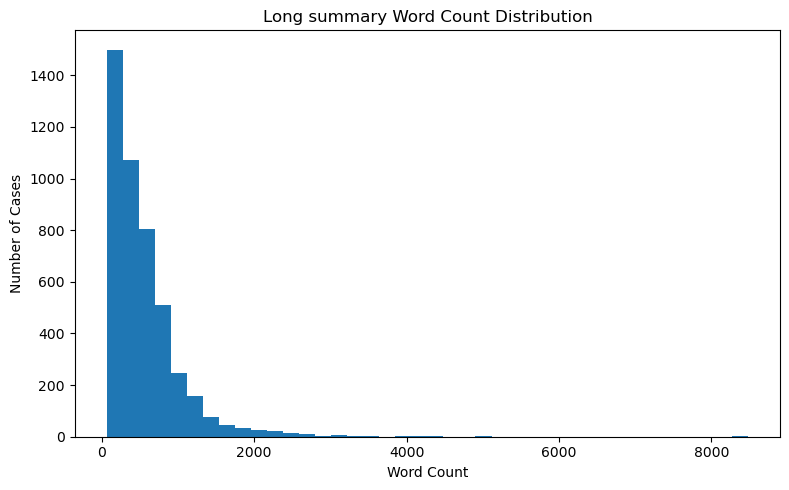

Long summary:
count    4539.000000
mean      545.719982
std       477.217516
min        65.000000
25%       222.000000
50%       419.000000
75%       705.000000
max      8481.000000
Name: ref_long_word_count, dtype: float64


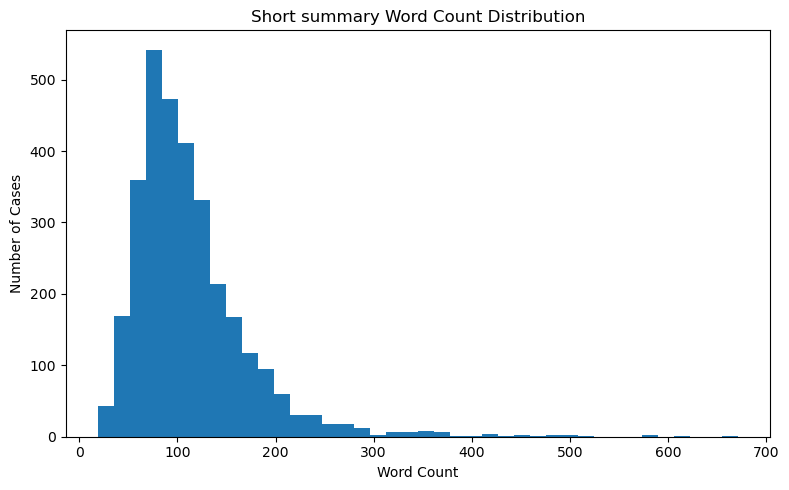

Short summary:
count    3138.000000
mean      112.968770
std        60.213431
min        19.000000
25%        75.000000
50%       100.000000
75%       135.000000
max       671.000000
Name: ref_short_word_count, dtype: float64


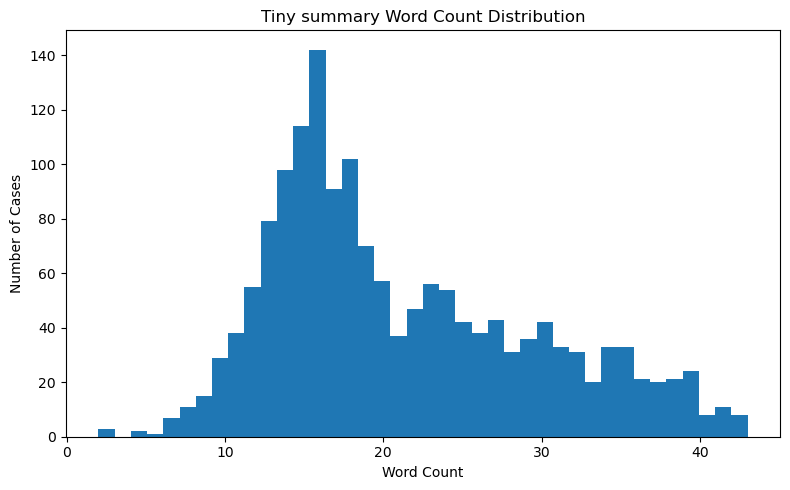

Tiny summary:
count    1603.000000
mean       21.181535
std         8.169100
min         2.000000
25%        15.000000
50%        19.000000
75%        27.000000
max        43.000000
Name: ref_tiny_word_count, dtype: float64


In [14]:
# Because source documents are extremely skewed, use log scale for source length.
plt.figure(figsize=(8, 5))
plt.hist(df["source_word_count"], bins=50)
plt.xscale("log")
plt.title("Source Document Word Count Distribution (Log Scale)")
plt.xlabel("Source Word Count, log scale")
plt.ylabel("Number of Cases")
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "source_word_count_distribution_log.png"
plt.savefig(fig_path, dpi=150)
plt.show()


# Reference summary length distributions
summary_length_cols = {
    "Long summary": "ref_long_word_count",
    "Short summary": "ref_short_word_count",
    "Tiny summary": "ref_tiny_word_count",
}

for title, col in summary_length_cols.items():
    nonzero_lengths = df.loc[df[col] > 0, col]

    plt.figure(figsize=(8, 5))
    plt.hist(nonzero_lengths, bins=40)
    plt.title(f"{title} Word Count Distribution")
    plt.xlabel("Word Count")
    plt.ylabel("Number of Cases")
    plt.tight_layout()

    safe_title = title.lower().replace(" ", "_")
    fig_path = PROJECT_ROOT / "outputs" / "figures" / f"{safe_title}_word_count_distribution.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print(f"{title}:")
    print(nonzero_lengths.describe())


### Key finding: summary lengths match the dataset design

The three reference summary levels show clear granularity differences. Long summaries have a median length of about 419 words, short summaries have a median length of about 100 words among available cases, and tiny summaries have a median length of about 19 words among available cases. This confirms that the dataset is designed for multi-granularity summarization.

In [15]:
tables_dir = PROJECT_ROOT / "outputs" / "tables"
samples_dir = PROJECT_ROOT / "outputs" / "samples"

class_action_table.to_csv(tables_dir / "class_action_sought_distribution.csv")
case_type_table.to_csv(tables_dir / "case_type_distribution.csv")
summary_availability_df.to_csv(tables_dir / "summary_availability.csv", index=False)

# Save a lightweight project dataframe sample for quick inspection.
df_light = df.drop(columns=["source_text", "case_metadata"]).copy()
df_light.to_csv(tables_dir / "multilexsum_metadata_light.csv", index=False)

# Save a tiny sample with source text for debugging later notebooks.
sample_cols = [
    "split",
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "source_text",
    "ref_long",
    "ref_short",
    "ref_tiny",
]
df[sample_cols].head(10).to_csv(samples_dir / "multilexsum_sample_10_cases.csv", index=False)


## Notebook 1 Summary: Key Data Findings

This notebook loaded the Multi-LexSum dataset using the required HuggingFace version: `allenai/multi_lexsum`, `name="v20230518"`.

### Dataset structure

The dataset contains **4,539 total civil rights cases** split into:

- Train: **3,177**
- Validation: **454**
- Test: **908**

The main text is stored in the `sources` field as a list of source documents. For modeling and analysis, the source documents were joined into a single `source_text` field. The target labels `class_action_sought` and `case_type` are nested inside `case_metadata`, so they must be extracted from that dictionary rather than treated as top-level dataset columns.

### Long-document challenge

The source documents are extremely long. The median case has about **24.5K words**, while the largest case exceeds **3.5M words**. This confirms that direct transformer summarization is not practical without truncation or chunking. The project will therefore use a hierarchical chunking strategy for summarization.

### Multi-granularity summaries

The dataset includes three levels of expert-authored summaries:

- Long summaries: available for **100%** of cases
- Short summaries: available for about **69.1%** of cases
- Tiny summaries: available for about **35.3%** of cases

Because short and tiny summaries are not available for every case, summary evaluation must filter to rows where the corresponding reference summary exists.

### Classification targets

The `class_action_sought` target is moderately imbalanced:

- No: **3,026** cases
- Yes: **1,510** cases
- Unknown: **3** cases

The `Unknown` group is too small for meaningful supervised modeling, so it should be removed or handled separately before binary classification.

The `case_type` target has **24 categories**, but the distribution is highly skewed. `Equal Employment` is the largest group, with **1,579 cases** or about **34.8%** of the dataset. For multiclass classification, focusing on the top case types is a reasonable strategy to reduce sparsity while still modeling more than two classes.

### Next step

Notebook 2 will clean the legal case text using two versions:

- `cleaned_text_summary`: light cleaning for summarization and display
- `cleaned_text_modeling`: stronger normalization for TF-IDF classification